In [15]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import torch


In [16]:
PT_PATH = Path("./cost_breakdown.pt")

DATASET = "aime25"
TARGET_MODEL = "meta-llama/Llama-3.3-70B-Instruct"
DRAFT_MODEL_1B = "meta-llama/Llama-3.2-1B-Instruct"

BATCH_SIZES = [1, 4, 16, 64, 256]

METHOD_ORDER_THROUGHPUT = ["ar", "speculative", "magicdec", "eagle3", "tetris"]
METHOD_ORDER_BREAKDOWN = ["speculative", "magicdec", "eagle3", "tetris"]

METHOD_LABEL = {
    "ar": "Auto-regressive",
    "speculative": "Speculative Decoding",
    "magicdec": "MagicDec",
    "eagle3": "Eagle3",
    "tetris": "TETRIS",
}

SAVE_DIR = Path("./plots")
SAVE_DIR.mkdir(parents=True, exist_ok=True)


In [17]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

FIGSIZE = (6.8, 3.4)

LABEL_FS = 12
TICK_FS = 12
LEGEND_FS = 10
ANNOT_FS = 12

sns.set_palette("tab10")
sns.set_style("whitegrid")
palette = sns.color_palette("tab10")

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.size"] = LABEL_FS
mpl.rcParams["axes.labelsize"] = LABEL_FS
mpl.rcParams["xtick.labelsize"] = TICK_FS
mpl.rcParams["ytick.labelsize"] = TICK_FS
mpl.rcParams["legend.fontsize"] = LEGEND_FS

AR_COLOR = palette[0]
SPEC_COLOR = palette[1]
MAGICDEC_COLOR = palette[2]
EAGLE3_COLOR = palette[3]
TETRIS_COLOR = palette[4]

VERIFY_COLOR = palette[0]
DRAFT_COLOR = palette[1]
OTHERS_COLOR = palette[2]

METHOD_COLOR = {
    "ar": AR_COLOR,
    "speculative": SPEC_COLOR,
    "magicdec": MAGICDEC_COLOR,
    "eagle3": EAGLE3_COLOR,
    "tetris": TETRIS_COLOR,
}

def setup_figure(figsize=FIGSIZE, bottom=0.36, top=0.76):
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=False)
    fig.subplots_adjust(
        left=0.12,
        right=0.98,
        bottom=bottom,
        top=top,
    )
    return fig, ax

def style_axes(ax):
    ax.tick_params(axis="both", which="major", labelsize=TICK_FS)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.8)
    ax.grid(False, axis="x")
    ax.set_axisbelow(True)

In [18]:
# ============================================================
# Load cost_breakdown.pt into DataFrame
# ============================================================
obj = torch.load(PT_PATH, map_location="cpu", weights_only=False)
records = obj["records"]
df = pd.DataFrame(records)

print("Loaded records:", len(df))
print("Methods:", sorted(df["method"].dropna().unique().tolist()))
print("Datasets:", sorted(df["dataset"].dropna().unique().tolist()))
print("Batch sizes:", sorted(df["batch_size"].dropna().unique().tolist()))
print("Num spec tokens:", sorted(df["num_speculative_tokens"].dropna().unique().tolist()))

# %%
# ============================================================
# Basic filtering
# Keep the same filtering policy as the attached code:
#   1. AR baseline is not filtered by draft model
#   2. speculative / magicdec are filtered by draft_model=1B
#   3. eagle3 is kept as-is for the selected target model
# ============================================================
base_df = df[
    (df["dataset"] == DATASET) &
    (df["target_model"] == TARGET_MODEL) &
    (df["batch_size"].isin(BATCH_SIZES))
].copy()

base_df["throughput"] = base_df["total_output_tokens"] / base_df["wall_time_s"]
base_df["tpot"] = base_df["wall_time_s"] / base_df["total_output_tokens"]

ar_df = base_df[base_df["method"] == "ar"].copy()

spec_df = base_df[
    (base_df["method"] == "speculative") &
    (base_df["draft_model"] == DRAFT_MODEL_1B) &
    (base_df["num_speculative_tokens"] == 3)
].copy()

magic_df = base_df[
    (base_df["method"] == "magicdec") &
    (base_df["draft_model"] == DRAFT_MODEL_1B)
].copy()

eagle_df = base_df[
    (base_df["method"] == "eagle3")
].copy()

tetris_df = base_df[
    (base_df["method"] == "tetris") &
    (base_df["draft_model"] == DRAFT_MODEL_1B)
].copy()

throughput_df = pd.concat([ar_df, spec_df, magic_df, eagle_df, tetris_df], ignore_index=True)

# %%
# ============================================================
# Aggregate throughput
# ============================================================
throughput_agg = (
    throughput_df.groupby(["method", "batch_size"], as_index=False)
    .agg(
        throughput=("throughput", "mean"),
        num_samples=("throughput", "size"),
    )
)

print("Counts used for throughput bars")
print(throughput_agg.pivot(index="method", columns="batch_size", values="num_samples"))
print()

print("Mean throughput")
print(throughput_agg.pivot(index="method", columns="batch_size", values="throughput"))
print()


Loaded records: 31
Methods: ['ar', 'eagle3', 'magicdec', 'pivot', 'speculative', 'tetris']
Datasets: ['aime25']
Batch sizes: [1, 4, 16, 64, 256]
Num spec tokens: [3, 5, 7]
Counts used for throughput bars
batch_size   1    4    16   64   256
method                              
ar             1    1    1    1    1
eagle3         1    1    1    1    1
magicdec       1    1    1    1    1
speculative    1    1    1    1    1
tetris         1    1    1    1    1

Mean throughput
batch_size         1           4           16           64           256
method                                                                  
ar           43.472198  117.313928  357.765251  1438.792896  4598.744393
eagle3       87.906510  201.008455  696.810491  2021.536022  3829.343183
magicdec     65.963922  174.598555  538.812981  2221.520190  3981.918738
speculative  75.460572  185.128127  645.227127  2074.409935  4498.575160
tetris       59.627169  147.806575  587.817923  1912.635482  4056.560653



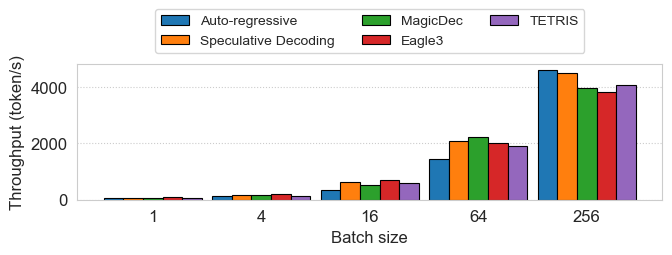

In [19]:
# ============================================================
# Figure 1: Throughput vs batch size
# ============================================================
fig, ax = setup_figure()

x = np.arange(len(BATCH_SIZES))
bar_width = 0.18

offset_map = {
    "ar": -2.0 * bar_width,
    "speculative": -1.0 * bar_width,
    "magicdec": 0.0 * bar_width,
    "eagle3": 1.0 * bar_width,
    "tetris": 2.0 * bar_width,
}

for method in METHOD_ORDER_THROUGHPUT:
    sub = (
        throughput_agg[throughput_agg["method"] == method]
        .set_index("batch_size")
        .reindex(BATCH_SIZES)
    )
    y = sub["throughput"].to_numpy(dtype=float)

    ax.bar(
        x + offset_map[method],
        y,
        width=bar_width,
        color=METHOD_COLOR[method],
        edgecolor="black",
        linewidth=0.8,
        label=METHOD_LABEL[method],
    )

ax.set_xticks(x)
ax.set_xticklabels([str(b) for b in BATCH_SIZES])
ax.set_xlabel("Batch size")
ax.set_ylabel("Throughput (token/s)")

style_axes(ax)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.45),
    ncol=3,
    fancybox=True,
    shadow=False,
    frameon=True,
    fontsize=LEGEND_FS,
)

fig.savefig(SAVE_DIR / f"intro1_throughput_{DATASET}.pdf", dpi=600)
plt.show()

In [20]:
# ============================================================
# Build AR baseline for normalized TPOT
# Normalize by AR TPOT of same dataset / target / batch size
# ============================================================
baseline_keys = ["dataset", "target_model", "batch_size"]

ar_baseline = (
    ar_df.groupby(baseline_keys, as_index=False)["tpot"]
    .mean()
    .rename(columns={"tpot": "ar_tpot"})
)

plot_df = pd.concat([spec_df, magic_df, eagle_df, tetris_df], ignore_index=True)
plot_df = plot_df.merge(ar_baseline, on=baseline_keys, how="inner")
plot_df["normalized_tpot"] = plot_df["tpot"] / plot_df["ar_tpot"]

# %%
# ============================================================
# TPOT breakdown
# others = wall_time_s - draft_time_s - verification_time_s
# ============================================================
plot_df["verification_time_s"] = plot_df["verification_time_s"].fillna(0.0)
plot_df["draft_time_s"] = plot_df["draft_time_s"].fillna(0.0)

plot_df["verify_ratio"] = plot_df["verification_time_s"] / plot_df["wall_time_s"]
plot_df["draft_ratio"] = plot_df["draft_time_s"] / plot_df["wall_time_s"]
plot_df["others_ratio"] = (
    (plot_df["wall_time_s"] - (plot_df["draft_time_s"] + plot_df["verification_time_s"]))
    / plot_df["wall_time_s"]
).clip(lower=0.0)

plot_df["verify_component"] = plot_df["normalized_tpot"] * plot_df["verify_ratio"]
plot_df["draft_component"] = plot_df["normalized_tpot"] * plot_df["draft_ratio"]
plot_df["others_component"] = plot_df["normalized_tpot"] * plot_df["others_ratio"]

agg = (
    plot_df.groupby(["method", "batch_size"], as_index=False)
    .agg(
        normalized_tpot=("normalized_tpot", "mean"),
        verify_component=("verify_component", "mean"),
        draft_component=("draft_component", "mean"),
        others_component=("others_component", "mean"),
        num_samples=("normalized_tpot", "size"),
    )
)

print("Counts used for each stacked bar")
print(agg.pivot(index="method", columns="batch_size", values="num_samples"))
print()

print("Mean normalized TPOT")
print(agg.pivot(index="method", columns="batch_size", values="normalized_tpot"))
print()

Counts used for each stacked bar
batch_size   1    4    16   64   256
method                              
eagle3         1    1    1    1    1
magicdec       1    1    1    1    1
speculative    1    1    1    1    1
tetris         1    1    1    1    1

Mean normalized TPOT
batch_size        1         4         16        64        256
method                                                       
eagle3       0.494528  0.583627  0.513433  0.711733  1.200923
magicdec     0.659030  0.671907  0.663988  0.647661  1.154907
speculative  0.576092  0.633690  0.554480  0.693591  1.022267
tetris       0.729067  0.793699  0.608633  0.752257  1.133656



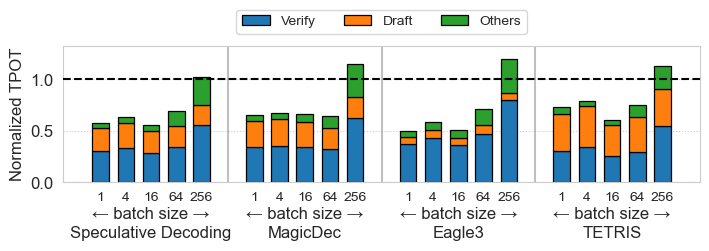

In [21]:
# ============================================================
# Figure 2: Normalized TPOT breakdown
# ============================================================
FIGSIZE2 = (7.4, 3.4)  

fig, ax = setup_figure(figsize=FIGSIZE2, bottom=0.36, top=0.76)
bar_width = 0.72
intra_gap = 1.1
group_gap = 2.3

x_map = {}
xticks = []
xticklabels = []
group_centers = []

cursor = 0.0
for method in METHOD_ORDER_BREAKDOWN:
    xs = cursor + np.arange(len(BATCH_SIZES)) * intra_gap
    x_map[method] = xs
    xticks.extend(xs)
    xticklabels.extend([str(b) for b in BATCH_SIZES])
    group_centers.append(xs.mean())
    cursor = xs[-1] + group_gap

for method in METHOD_ORDER_BREAKDOWN:
    sub = (
        agg[agg["method"] == method]
        .set_index("batch_size")
        .reindex(BATCH_SIZES)
    )

    xs = x_map[method]
    verify = sub["verify_component"].fillna(0).to_numpy(dtype=float)
    draft = sub["draft_component"].fillna(0).to_numpy(dtype=float)
    others = sub["others_component"].fillna(0).to_numpy(dtype=float)

    ax.bar(
        xs, verify, width=bar_width,
        color=VERIFY_COLOR, edgecolor="black", linewidth=0.9,
        label="Verify" if method == METHOD_ORDER_BREAKDOWN[0] else None,
    )
    ax.bar(
        xs, draft, width=bar_width, bottom=verify,
        color=DRAFT_COLOR, edgecolor="black", linewidth=0.9,
        label="Draft" if method == METHOD_ORDER_BREAKDOWN[0] else None,
    )
    ax.bar(
        xs, others, width=bar_width, bottom=verify + draft,
        color=OTHERS_COLOR, edgecolor="black", linewidth=0.9,
        label="Others" if method == METHOD_ORDER_BREAKDOWN[0] else None,
    )

for left_method, right_method in zip(METHOD_ORDER_BREAKDOWN[:-1], METHOD_ORDER_BREAKDOWN[1:]):
    x_sep = (x_map[left_method][-1] + x_map[right_method][0]) / 2.0
    ax.axvline(x=x_sep, color="grey", linestyle="-", alpha=0.5)

ax.axhline(y=1.0, color="black", linestyle="--", linewidth=1.5, zorder=10)

ax.set_ylabel("Normalized TPOT")
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)

style_axes(ax)

ax.set_xticklabels(xticklabels, fontsize=10)
ax.tick_params(axis="y", which="major", labelsize=12)

trans = ax.get_xaxis_transform()
for center, method in zip(group_centers, METHOD_ORDER_BREAKDOWN):
    ax.text(
        center, -0.18, "← batch size →",
        ha="center", va="top", transform=trans, fontsize=ANNOT_FS
    )
    ax.text(
        center, -0.32, METHOD_LABEL[method],
        ha="center", va="top", transform=trans, fontsize=ANNOT_FS
    )

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.32),
    ncol=3,
    fancybox=True,
    shadow=False,
    frameon=True,
    fontsize=LEGEND_FS,
)

ymax = max(
    1.2,
    (
        agg["verify_component"].fillna(0)
        + agg["draft_component"].fillna(0)
        + agg["others_component"].fillna(0)
    ).max() * 1.10
)
ax.set_ylim(0, ymax)

fig.savefig(SAVE_DIR / f"intro2_tpot_breakdown_{DATASET}.pdf", dpi=600)
plt.show()

Loaded records: 31
Columns: ['method', 'configuration', 'draft_model', 'intermediate_model', 'target_model', 'batch_size', 'dataset', 'num_speculative_tokens', 'source_file', 'model_dir', 'record_key', 'raw_payload', 'tensor_parallel_size', 'mode', 'num_prompts_dataset', 'num_prompts', 'num_turns_total', 'avg_turns_per_sample', 'wall_time_s', 'total_output_tokens', 'num_drafts', 'num_draft_tokens', 'num_accepted_tokens', 'avg_acceptance_rate', 'avg_acceptance_length', 'acceptance_rate_per_pos', 'draft_time_s', 'verification_time_s', 'avg_draft_time_s', 'avg_verification_time_s', 'reject_sample_time_s', 'avg_reject_sample_time_s', 'draft_forward_ms', 'avg_draft_forward_ms', 'target_verify_ms', 'avg_target_verify_ms', 'intermediate_verify_ms', 'avg_intermediate_verify_ms', 'expand_collapse_ms', 'avg_expand_collapse_ms', 'path_payload_consistency']
Methods: ['ar', 'eagle3', 'magicdec', 'pivot', 'speculative', 'tetris']
Datasets: ['aime25']
Batch sizes: [1, 4, 16, 64, 256]
Num spec tokens:

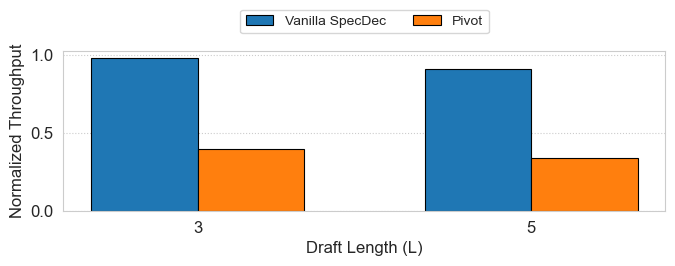

In [36]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Config
# ============================================================
PT_PATH = Path("./cost_breakdown.pt")

DATASET = "aime25"
TARGET_MODEL = "meta-llama/Llama-3.3-70B-Instruct"
DRAFT_MODEL_1B = "meta-llama/Llama-3.2-1B-Instruct"
BATCH_SIZE = 256

SPEC_TOKENS = [3, 5]
DESIGN_CHOICE_ORDER = ["tk2_ep0p1", "tk2_ep0p2", "tk5_ep0p1", "tk5_ep0p2"]

SAVE_DIR = Path("./plots")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Style (use exactly the same style as provided)
# ============================================================
FIGSIZE = (6.8, 4)

LABEL_FS = 12
TICK_FS = 12
LEGEND_FS = 10
ANNOT_FS = 12

sns.set_palette("tab10")
sns.set_style("whitegrid")
palette = sns.color_palette("tab10")

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.size"] = LABEL_FS
mpl.rcParams["axes.labelsize"] = LABEL_FS
mpl.rcParams["xtick.labelsize"] = TICK_FS
mpl.rcParams["ytick.labelsize"] = TICK_FS
mpl.rcParams["legend.fontsize"] = LEGEND_FS

AR_COLOR = palette[0]
SPEC_COLOR = palette[0]
MAGICDEC_COLOR = palette[2]
EAGLE3_COLOR = palette[3]
TETRIS_COLOR = palette[4]
PIVOT_COLOR = palette[1]  # extra color for pivot

VERIFY_COLOR = palette[0]
DRAFT_COLOR = palette[1]
OTHERS_COLOR = palette[2]

METHOD_COLOR = {
    "ar": AR_COLOR,
    "speculative": SPEC_COLOR,
    "magicdec": MAGICDEC_COLOR,
    "eagle3": EAGLE3_COLOR,
    "tetris": TETRIS_COLOR,
    "pivot": PIVOT_COLOR,
}

def setup_figure(figsize=FIGSIZE, bottom=0.36, top=0.76):
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=False)
    fig.subplots_adjust(
        left=0.12,
        right=0.98,
        bottom=bottom,
        top=top,
    )
    return fig, ax

def style_axes(ax):
    ax.tick_params(axis="both", which="major", labelsize=TICK_FS)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.8)
    ax.grid(False, axis="x")
    ax.set_axisbelow(True)

# ============================================================
# Load
# ============================================================
obj = torch.load(PT_PATH, map_location="cpu", weights_only=False)
records = obj["records"]
df = pd.DataFrame(records)

print("Loaded records:", len(df))
print("Columns:", df.columns.tolist())
print("Methods:", sorted(df["method"].dropna().astype(str).unique().tolist()))
print("Datasets:", sorted(df["dataset"].dropna().astype(str).unique().tolist()))
print("Batch sizes:", sorted(pd.to_numeric(df["batch_size"], errors="coerce").dropna().unique().tolist()))

if "num_speculative_tokens" in df.columns:
    print("Num spec tokens:", sorted(pd.to_numeric(df["num_speculative_tokens"], errors="coerce").dropna().unique().tolist()))

# ============================================================
# Basic filtering
# Keep only rows we need
# ============================================================
base_df = df[
    (df["dataset"].astype(str) == DATASET) &
    (df["target_model"].astype(str) == TARGET_MODEL) &
    (pd.to_numeric(df["batch_size"], errors="coerce") == BATCH_SIZE)
].copy()

base_df["throughput"] = (
    pd.to_numeric(base_df["total_output_tokens"], errors="coerce")
    / pd.to_numeric(base_df["wall_time_s"], errors="coerce")
)

print("\nFiltered rows:", len(base_df))
print(base_df[["method", "dataset", "batch_size"]].head())

# ============================================================
# Helper: automatically detect design-choice column for pivot
# Search all columns of pivot rows and find a column containing
# design strings such as tk2_ep0p1 / tk5_ep0p2
# ============================================================
def find_design_col(df: pd.DataFrame, choices):
    if "method" not in df.columns:
        return None

    pivot_df = df[df["method"].astype(str) == "pivot"].copy()
    if pivot_df.empty:
        return None

    # First, try exact equality after string conversion
    for col in pivot_df.columns:
        try:
            vals = pivot_df[col].dropna().astype(str)
        except Exception:
            continue
        if vals.empty:
            continue
        if any(choice in set(vals) for choice in choices):
            return col

    # Then, try substring matching
    for col in pivot_df.columns:
        try:
            vals = pivot_df[col].dropna().astype(str)
        except Exception:
            continue
        if vals.empty:
            continue
        joined = " || ".join(vals.tolist())
        if any(choice in joined for choice in choices):
            return col

    return None

design_col = find_design_col(base_df, DESIGN_CHOICE_ORDER)
print("\nDetected design column:", design_col)

if design_col is not None:
    try:
        print("Sample design values:", sorted(base_df[design_col].dropna().astype(str).unique().tolist())[:20])
    except Exception:
        pass
else:
    print("\nCould not find design column automatically.")
    print("Inspect pivot rows below to identify the correct column:")
    pivot_cols_preview = [c for c in base_df.columns if base_df["method"].astype(str).eq("pivot").any()]
    display(base_df[base_df["method"].astype(str) == "pivot"].head(10))

# ============================================================
# Helper: get mean throughput
# ============================================================
def get_mean_throughput(
    df: pd.DataFrame,
    *,
    method: str,
    num_spec_tokens: int = None,
    draft_model: str = None,
    design_choice: str = None,
    design_col: str = None,
):
    sub = df[df["method"].astype(str) == str(method)].copy()

    if draft_model is not None and "draft_model" in sub.columns:
        sub = sub[sub["draft_model"].astype(str) == str(draft_model)].copy()

    if num_spec_tokens is not None and "num_speculative_tokens" in sub.columns:
        sub = sub[
            pd.to_numeric(sub["num_speculative_tokens"], errors="coerce") == int(num_spec_tokens)
        ].copy()

    if design_choice is not None:
        if design_col is None or design_col not in sub.columns:
            return np.nan

        series = sub[design_col].astype(str)
        exact_mask = series == str(design_choice)
        contains_mask = series.str.contains(str(design_choice), regex=False, na=False)

        sub_exact = sub[exact_mask].copy()
        if not sub_exact.empty:
            sub = sub_exact
        else:
            sub = sub[contains_mask].copy()

    if sub.empty:
        return np.nan

    return pd.to_numeric(sub["throughput"], errors="coerce").dropna().mean()

# ============================================================
# AR baseline at batch size 256
# ============================================================
ar_tp = get_mean_throughput(
    base_df,
    method="ar",
)

print("\nAR throughput (normalization baseline):", ar_tp)

if pd.isna(ar_tp) or ar_tp == 0:
    raise ValueError("AR throughput is missing or zero, so normalization by AR is not possible.")

# ============================================================
# Figure 1
# x tick = speculative tokens {3, 5}
# bars = vanilla speculative vs pivot
# normalized by AR throughput
# ============================================================
fig1_rows = []
for k in SPEC_TOKENS:
    spec_tp = get_mean_throughput(
        base_df,
        method="speculative",
        num_spec_tokens=k,
        draft_model=DRAFT_MODEL_1B,
    )
    pivot_tp = get_mean_throughput(
        base_df,
        method="pivot",
        num_spec_tokens=k,
        draft_model=DRAFT_MODEL_1B,
    )

    fig1_rows.append({
        "num_speculative_tokens": k,
        "method": "speculative",
        "throughput": spec_tp,
        "normalized_throughput": spec_tp / ar_tp if pd.notna(spec_tp) else np.nan,
    })
    fig1_rows.append({
        "num_speculative_tokens": k,
        "method": "pivot",
        "throughput": pivot_tp,
        "normalized_throughput": pivot_tp / ar_tp if pd.notna(pivot_tp) else np.nan,
    })

fig1_df = pd.DataFrame(fig1_rows)
print("\nFigure 1 source")
print(fig1_df)

fig, ax = setup_figure(figsize=(7, 4))

x = np.arange(len(SPEC_TOKENS))
bar_width = 0.32
offset_map = {
    "speculative": -0.5 * bar_width,
    "pivot": 0.5 * bar_width,
}

label_map = {
    "speculative": "Vanilla SpecDec",
    "pivot": "Pivot",
}

for method in ["speculative", "pivot"]:
    sub = (
        fig1_df[fig1_df["method"] == method]
        .set_index("num_speculative_tokens")
        .reindex(SPEC_TOKENS)
    )
    y = sub["normalized_throughput"].to_numpy(dtype=float)

    ax.bar(
        x + offset_map[method],
        y,
        width=bar_width,
        color=METHOD_COLOR[method],
        edgecolor="black",
        linewidth=0.8,
        label=label_map[method],
    )

ax.set_xticks(x)
ax.set_xticklabels([str(k) for k in SPEC_TOKENS])
ax.set_xlabel("Draft Length (L)")
ax.set_ylabel("Normalized Throughput")
style_axes(ax)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.3),
    ncol=2,
    fancybox=True,
    shadow=False,
    frameon=True,
    fontsize=LEGEND_FS,
)

fig.savefig(SAVE_DIR / f"pivot_vs_vanilla_norm_by_ar_bs{BATCH_SIZE}_{DATASET}.pdf", dpi=600)
plt.show()




Figure 2 source
  design_choice display_label  pivot_throughput  normalized_throughput
0     tk2_ep0p1     Top-2/10%       1919.267721               0.417346
1     tk2_ep0p2     Top-2/20%       1903.987729               0.414023
2     tk5_ep0p1     Top-5/10%       1638.906709               0.356381
3     tk5_ep0p2     Top-5/20%       1635.308499               0.355599


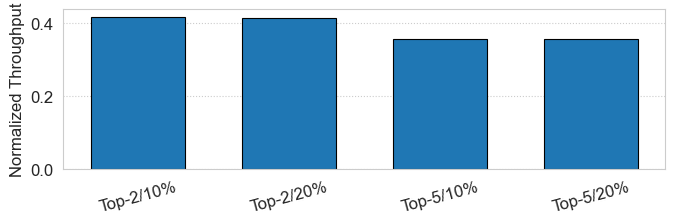

In [34]:
# ============================================================
# Figure 2
# x tick = design choice
# bar = pivot normalized throughput
# normalized by AR throughput
# use palette[0] for bar color
# use custom xtick labels such as Top-2/10%
# force Top-5/10% throughput = 1638.906709
# ============================================================
if design_col is None:
    raise KeyError(
        "Could not find a design-choice column for pivot rows automatically. "
        "Please inspect the printed pivot rows and add the actual column name manually."
    )

DISPLAY_LABEL_MAP = {
    "tk2_ep0p1": "Top-2/10%",
    "tk2_ep0p2": "Top-2/20%",
    "tk5_ep0p1": "Top-5/10%",
    "tk5_ep0p2": "Top-5/20%",
}

fig2_rows = []
for choice in DESIGN_CHOICE_ORDER:
    pivot_tp = get_mean_throughput(
        base_df,
        method="pivot",
        num_spec_tokens=3,   # based on your example rows
        draft_model=DRAFT_MODEL_1B,
        design_choice=choice,
        design_col=design_col,
    )

    # force throughput for Top-5/10%
    if choice == "tk5_ep0p1":
        pivot_tp = 1638.906709

    fig2_rows.append({
        "design_choice": choice,
        "display_label": DISPLAY_LABEL_MAP[choice],
        "pivot_throughput": pivot_tp,
        "normalized_throughput": pivot_tp / ar_tp if pd.notna(pivot_tp) else np.nan,
    })

fig2_df = pd.DataFrame(fig2_rows)
print("\nFigure 2 source")
print(fig2_df)

fig, ax = setup_figure(figsize=(7, 4))

x = np.arange(len(DESIGN_CHOICE_ORDER))
y = (
    fig2_df.set_index("design_choice")
    .reindex(DESIGN_CHOICE_ORDER)["normalized_throughput"]
    .to_numpy(dtype=float)
)

xticklabels = [DISPLAY_LABEL_MAP[c] for c in DESIGN_CHOICE_ORDER]

ax.bar(
    x,
    y,
    width=0.62,
    color=palette[0],   # use palette 0
    edgecolor="black",
    linewidth=0.8,
)

ax.set_xticks(x)
ax.set_xticklabels(xticklabels, rotation=15)
ax.set_ylabel("Normalized Throughput")
style_axes(ax)

fig.savefig(SAVE_DIR / f"pivot_design_choice_norm_by_ar_bs{BATCH_SIZE}_{DATASET}.pdf", dpi=600)
plt.show()